<a href="https://colab.research.google.com/github/kuxx12257/machine_learnng_COOKBOOK/blob/branch1/CustomerServiceClassifier_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A K NEAREST NEIGHBOR MODEL THAT HELPS TO CLASSIFY THE CUSTOMERS ON THE BASIS OF DEMOGRAPHIC DATA INTO 4 CATEORIES DEPENDIG ON THE TYPE OF SERVICES PREFERRED

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pylab as pl
from sklearn import preprocessing


In [3]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [5]:
df.columns

Index(['region', 'tenure', 'age', 'marital', 'address', 'income', 'ed',
       'employ', 'retire', 'gender', 'reside', 'custcat'],
      dtype='object')

array([[<Axes: title={'center': 'income'}>]], dtype=object)

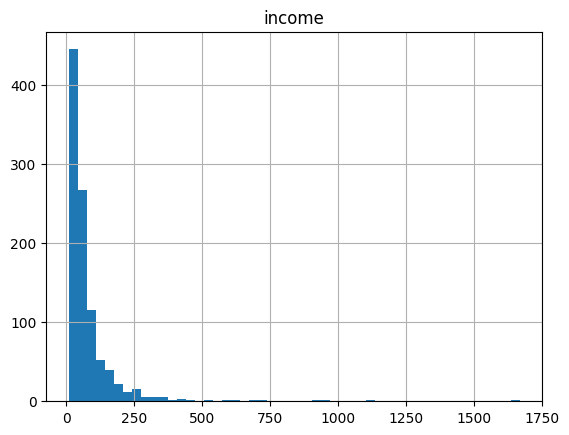

In [11]:
df.hist(column="income",bins=50)

In [12]:
x=df[['region', 'tenure', 'age', 'marital', 'address', 'income', 'ed',
       'employ', 'retire', 'gender', 'reside']]

In [19]:

y=df[["custcat"]].values

In [21]:
#normaliing the dataset
x=preprocessing.StandardScaler().fit(x).transform(x.astype(float))

In [22]:
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,random_state=4)
print(train_x.shape,train_y.shape)

(800, 11) (800, 1)


In [36]:
Ks =200
mean_acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))

for n in range(100,Ks):

    #Train Model and Predict
    neigh = KNeighborsClassifier(n_neighbors = n).fit(train_x,train_y)
    yhat=neigh.predict(test_x)
    mean_acc[n-1] = metrics.accuracy_score(test_y,test_Y)


    std_acc[n-1]=np.std(test_Y==test_y)/np.sqrt(test_Y.shape[0])

mean_acc

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31,
       0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31,
       0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31,
       0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31,
       0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.31, 0.

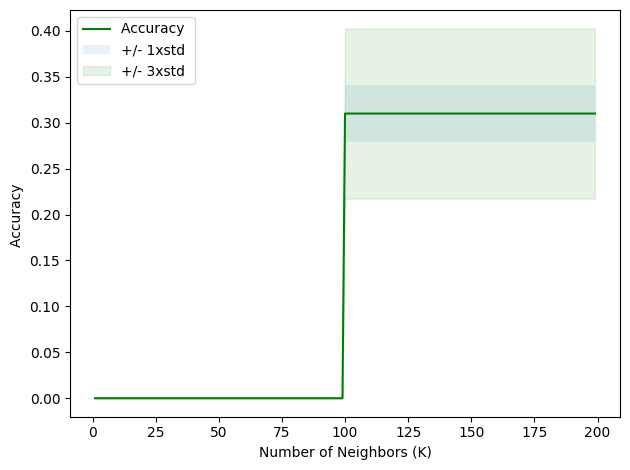

In [37]:
plt.plot(range(1,Ks),mean_acc,'g')
plt.fill_between(range(1,Ks),mean_acc - 1 * std_acc,mean_acc + 1 * std_acc, alpha=0.10)
plt.fill_between(range(1,Ks),mean_acc - 3 * std_acc,mean_acc + 3 * std_acc, alpha=0.10,color="green")
plt.legend(('Accuracy ', '+/- 1xstd','+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

In [38]:
print( "The best accuracy was with", mean_acc.max(), "with k=", mean_acc.argmax()+1)

The best accuracy was with 0.31 with k= 100


In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [29]:
k=100
#train model and predict
neigh=KNeighborsClassifier(n_neighbors=k).fit(train_x,train_y.ravel())
neigh

KNeighborsClassifier(n_neighbors=100)

In [30]:
test_Y=neigh.predict(test_x)
print(test_Y[0:5])

[1 1 4 4 4]


In [31]:
from sklearn import metrics

In [32]:
print("the accuracy score is :",metrics.accuracy_score(test_Y,test_y))

the accuracy score is : 0.31
